In [ ]:
# %%
%pip install accelerate datasets evaluate rouge_score bert_score sacrebleu -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install transformers==4.45.2 trl==0.11.3 -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# %%
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline
)
from trl import (
    PPOConfig,
    PPOTrainer,
    AutoModelForCausalLMWithValueHead,
    SFTTrainer,
    SFTConfig
)
import evaluate

/home/hoang/miniconda3/envs/rlhf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# %%
# ================= CONFIG =================

MODEL_NAME = "gpt2"
DATASET_NAME = "HumanLLMs/Human-Like-DPO-Dataset"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 4
EPOCHS = 1
LEARNING_RATE = 5e-6
MAX_LENGTH = 512
MAX_RESPONSE_LENGTH = 128

EXP_NAME = "ppo_gpt2"

BASE_DIR = f"runs/{EXP_NAME}"
CKPT_DIR = f"{BASE_DIR}/checkpoints"
LOG_DIR = f"{BASE_DIR}/logs"
PLOT_DIR = f"{BASE_DIR}/plots"

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

In [ ]:
# %%
# ================= DATA =================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "left"

dataset = load_dataset(DATASET_NAME, split="train").train_test_split(test_size=0.2)

train_dataset = dataset["train"].select(range(min(len(dataset["train"]), 2048)))
eval_dataset = dataset["test"].select(range(min(len(dataset["test"]), 512)))

def format_for_rlhf(example):
    return {
        "query": example["prompt"]
    }

train_dataset = train_dataset.map(format_for_rlhf)
eval_dataset = eval_dataset.map(format_for_rlhf)

def tokenize_fn(batch):
    tokens = tokenizer(
        batch["query"],
        padding="max_length",
        truncation=True,
        max_length=512
    )
    batch["input_ids"] = tokens["input_ids"]
    batch["attention_mask"] = tokens["attention_mask"]
    return batch

tokenized_train_dataset = train_dataset.map(tokenize_fn, batched=True)

tokenized_train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask"],
    output_all_columns=True
)

Map: 100%|██████████| 2048/2048 [00:00<00:00, 7559.15 examples/s]


In [ ]:
# %%
# ================= SFT =================

sft_config = SFTConfig(
    output_dir=f"{CKPT_DIR}/sft",
    dataset_text_field="chosen",
    per_device_train_batch_size=BATCH_SIZE,
    learning_rate=2e-5,
    num_train_epochs=1,
    logging_steps=10,
    max_seq_length=512,
    max_steps=1000,
    fp16=torch.cuda.is_available()
)

sft_trainer = SFTTrainer(
    model=MODEL_NAME,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=sft_config
)

print("Training SFT...")
sft_trainer.train()
sft_trainer.save_model(f"{CKPT_DIR}/sft_model")

/home/hoang/miniconda3/envs/rlhf/lib/python3.11/site-packages/trl/trainer/sft_trainer.py:185: UserWarning: You passed a model_id to the SFTTrainer. This will automatically create an `AutoModelForCausalLM` or a `PeftModel` (if you passed a `peft_config`) for you.
  warnings.warn(
Map: 100%|██████████| 512/512 [00:00<00:00, 9492.90 examples/s]
max_steps is given, it will override any value given in num_train_epochs


Training SFT...


Step,Training Loss
10,2.816900
20,2.695000
30,2.657300
40,2.568400
50,2.531000
60,2.495200
70,2.514100
80,2.465100
90,2.431100
100,2.401700


In [ ]:
def tokenize_pair(example):
    chosen = tokenizer(example["chosen"], truncation=True, padding="max_length", max_length=512)
    rejected = tokenizer(example["rejected"], truncation=True, padding="max_length", max_length=512)

    return {
        "input_ids_chosen": chosen["input_ids"],
        "mask_chosen": chosen["attention_mask"],
        "input_ids_rejected": rejected["input_ids"],
        "mask_rejected": rejected["attention_mask"]
    }

def reward_loss_batched(model, batch, label_smoothing=0.1):
    chosen_rewards = model(input_ids=batch["input_ids_chosen"].to(DEVICE), 
                           attention_mask=batch["mask_chosen"].to(DEVICE)).logits
    rejected_rewards = model(input_ids=batch["input_ids_rejected"].to(DEVICE), 
                             attention_mask=batch["mask_rejected"].to(DEVICE)).logits
    
    # Label Smoothing implementation
    loss = -torch.nn.functional.logsigmoid(chosen_rewards - rejected_rewards)
    if label_smoothing > 0:
        loss = loss * (1 - label_smoothing) + 0.5 * label_smoothing
        
    return loss.mean()

In [ ]:
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

reward_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1
)

reward_model.config.pad_token_id = tokenizer.eos_token_id

reward_train = train_dataset.map(tokenize_pair, remove_columns=train_dataset.column_names)

# --- 1. Setup DataLoader ---
reward_train.set_format(type='torch', columns=['input_ids_chosen', 'mask_chosen', 'input_ids_rejected', 'mask_rejected'])
train_loader = DataLoader(reward_train, batch_size=BATCH_SIZE, shuffle=True)

# --- 2. Optimizer with Weight Decay ---
# Weight decay (0.01) is a strong anti-overfitting tool
optimizer = AdamW(reward_model.parameters(), lr=5e-6, weight_decay=0.01)

# --- 3. Learning Rate Scheduler ---
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 2048/2048 [00:02<00:00, 959.75 examples/s] 


In [ ]:
print("Training Reward Model...")
reward_model.to(DEVICE)

reward_history = []
global_step = 0
best_loss = float("inf")

for epoch in range(EPOCHS):
    epoch_losses = []
    for step, batch in enumerate(train_loader):
        loss = reward_loss_batched(reward_model, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(reward_model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()
        loss_val = loss.item()
        reward_history.append({
            "step": global_step,
            "epoch": epoch,
            "loss": loss_val
        })
        epoch_losses.append(loss_val)
        if global_step % 10 == 0:
            print(f"[RM] Epoch {epoch} Step {global_step} Loss {loss_val:.4f}")
        if global_step % 20 == 0 and global_step > 0:
            ckpt_path = f"{CKPT_DIR}/reward_model_step_{global_step}"
            reward_model.save_pretrained(ckpt_path)
        if loss_val < best_loss:
            best_loss = loss_val
            reward_model.save_pretrained(f"{CKPT_DIR}/reward_model_best")
        # Early Stopping: If loss < 0.01, stop training to prevent memorization
        if loss.item() < 0.01:
            print("Loss threshold reached. Stopping to prevent overfitting.")
            break
        global_step += 1
    print(f"[RM] Epoch {epoch} Mean Loss {np.mean(epoch_losses):.4f}")

# final save
reward_model.save_pretrained(f"{CKPT_DIR}/reward_model_final")


Training Reward Model...
[RM] Epoch 0 Step 0 Loss 0.9527
[RM] Epoch 0 Step 10 Loss 0.6709
[RM] Epoch 0 Step 20 Loss 0.9623
[RM] Epoch 0 Step 30 Loss 0.6062
[RM] Epoch 0 Step 40 Loss 0.8605
[RM] Epoch 0 Step 50 Loss 1.0441
[RM] Epoch 0 Step 60 Loss 0.6795
[RM] Epoch 0 Step 70 Loss 0.4590
[RM] Epoch 0 Step 80 Loss 0.7962
[RM] Epoch 0 Step 90 Loss 0.5520
[RM] Epoch 0 Step 100 Loss 0.8346
[RM] Epoch 0 Step 110 Loss 1.7424
[RM] Epoch 0 Step 120 Loss 1.7828
[RM] Epoch 0 Step 130 Loss 1.2619
[RM] Epoch 0 Step 140 Loss 0.4612
[RM] Epoch 0 Step 150 Loss 1.2385
[RM] Epoch 0 Step 160 Loss 0.3099
[RM] Epoch 0 Step 170 Loss 1.8874
[RM] Epoch 0 Step 180 Loss 0.8873
[RM] Epoch 0 Step 190 Loss 0.7806
[RM] Epoch 0 Step 200 Loss 0.6592
[RM] Epoch 0 Step 210 Loss 0.8146
[RM] Epoch 0 Step 220 Loss 0.7037
[RM] Epoch 0 Step 230 Loss 0.6896
[RM] Epoch 0 Step 240 Loss 0.7358
[RM] Epoch 0 Step 250 Loss 0.8705
[RM] Epoch 0 Step 260 Loss 0.8092
[RM] Epoch 0 Step 270 Loss 0.8948
[RM] Epoch 0 Step 280 Loss 0.5090


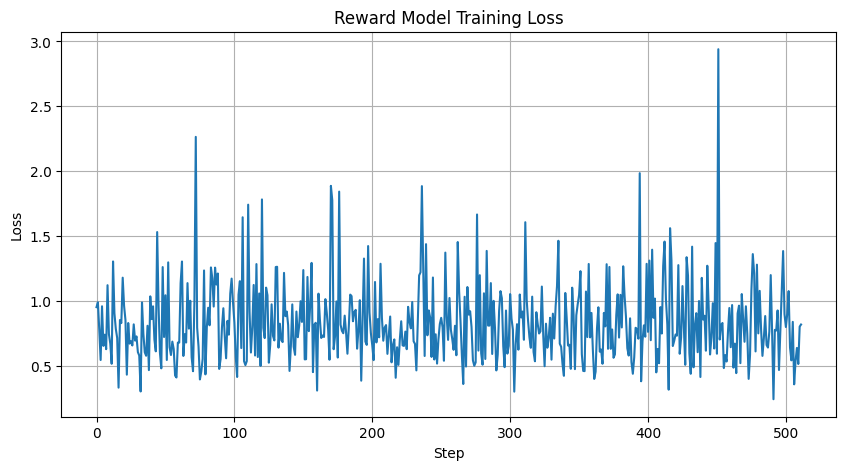

Reward model training complete.


In [ ]:
# ================= STORE HISTORY =================

history_df = pd.DataFrame(reward_history)
history_df.to_csv(f"{BASE_DIR}/reward_training_log.csv", index=False)

with open(f"{BASE_DIR}/reward_training_summary.txt", "w") as f:
    f.write(f"Best Loss: {best_loss}\n")
    f.write(f"Total Steps: {global_step}\n")

# ================= PLOT =================

plt.figure(figsize=(10,5))
plt.plot(history_df["step"], history_df["loss"])
plt.title("Reward Model Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid()
plt.savefig(f"{PLOT_DIR}/reward_loss_curve.png")
plt.show()

print("Reward model training complete.")

In [ ]:
# %%
# ================= PPO =================

policy_model = AutoModelForCausalLMWithValueHead.from_pretrained(f"{CKPT_DIR}/sft_model")
ref_model = AutoModelForCausalLMWithValueHead.from_pretrained(f"{CKPT_DIR}/sft_model")

reward_model = AutoModelForSequenceClassification.from_pretrained(
    f"{CKPT_DIR}/reward_model_best"
)

tokenizer = AutoTokenizer.from_pretrained(f"{CKPT_DIR}/sft_model")
tokenizer.padding_side = "left"

reward_pipe = pipeline(
    "sentiment-analysis",
    model=reward_model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

ppo_config = PPOConfig(
    # 1. Drop the learning rate significantly
    learning_rate=5e-7,           
    
    # 2. Increase the "tether" to the reference model
    init_kl_coef=0.5,             # Start with a much higher penalty (was 0.05)
    target_kl=0.1,               # Aim for a tighter KL divergence
    adap_kl_ctrl=True,            
    
    # 3. Increase the batch size for more stable gradients
    batch_size=64,                # If memory allows, larger is smoother
    mini_batch_size=4,            
    
    # 4. Standard PPO stability settings
    ppo_epochs=4,
    gradient_accumulation_steps=1,
    max_grad_norm=0.5,
    use_score_scaling=False,      # Keep our manual scaling
    use_score_norm=True           # Tell TRL to normalize the rewards again internally
)

ppo_trainer = PPOTrainer(
    config=ppo_config,
    model=policy_model,
    ref_model=ref_model,
    tokenizer=tokenizer,
    dataset=tokenized_train_dataset
)

gen_kwargs = dict(
    max_new_tokens=64,
    min_new_tokens=10,
    do_sample=True,
    top_k=40,                     # Narrower sampling to avoid "trash" tokens
    top_p=0.85,
    temperature=0.7,              # Lower temperature = less "random" exploration
    repetition_penalty=1.3,       # High penalty to stop the model from repeating "reward hacks"
    no_repeat_ngram_size=3,
    pad_token_id=tokenizer.eos_token_id,
    eos_token_id=tokenizer.eos_token_id,
)

/home/hoang/miniconda3/envs/rlhf/lib/python3.11/site-packages/trl/trainer/ppo_config.py:207: FutureWarning: `PPOConfig` is deprecated and will be removed in the future. Please use `PPOv2Config` with `PPOv2Trainer` instead.
  warnings.warn(
/home/hoang/miniconda3/envs/rlhf/lib/python3.11/site-packages/trl/trainer/ppo_trainer.py:193: FutureWarning: `PPOTrainer` is deprecated and will be removed in trl v0.12. Please use `PPOv2Trainer` instead.
  warnings.warn(


In [ ]:
print("Starting PPO Training...")

ppo_history = []
log_every = 10

for step, batch in enumerate(ppo_trainer.dataloader):
    # Convert from [batch_size, seq_len] tensor to a list of [seq_len] tensors
    query_tensors = [q for q in batch["input_ids"]] 
    # ---------------

    # 2. Generate responses (Now this will work!)
    response_tensors = ppo_trainer.generate(query_tensors, **gen_kwargs)
    responses = [tokenizer.decode(r, skip_special_tokens=True) for r in response_tensors]

    # 3. Compute rewards
    # Ensure we use the 'query' from the batch (text) + our generated responses
    texts = [q + r for q, r in zip(batch["query"], responses)]
    pipe_outputs = reward_pipe(texts)
    
    # --- FIXED LINE ---
    current_device = ppo_trainer.model.pretrained_model.device
    raw_rewards_tensor = torch.tensor([o["score"] for o in pipe_outputs], device=current_device)
    # ------------------

    # 4. Normalize + Clamp
    mean_r = raw_rewards_tensor.mean()
    std_r = raw_rewards_tensor.std() + 1e-6
    
    rewards_tensor = (raw_rewards_tensor - mean_r) / std_r
    rewards_tensor = torch.clamp(rewards_tensor, min=-2.0, max=2.0)

    rewards_list = [r for r in rewards_tensor] 

    stats = ppo_trainer.step(query_tensors, response_tensors, rewards_list)
    
    # log_stats also prefers the list format
    ppo_trainer.log_stats(stats, batch, rewards_list)

    # 6. Track values (Using .get() safely)
    step_data = {
        "step": step,
        "kl": stats.get("objective/kl", 0.0),
        "reward_mean": rewards_tensor.mean().item(),
        "reward_std": rewards_tensor.std().item(),
        "loss": stats.get("ppo/loss/total", 0.0),
        "entropy": stats.get("objective/entropy", 0.0),
        "ratio_mean": stats.get("ppo/policy/ratio_mean", 1.0),
        "ratio_max": stats.get("ppo/policy/ratio_max", 1.0),
    }
    ppo_history.append(step_data)

    # 7. Print diagnostics
    if step % log_every == 0:
        print(
            f"Step {step} | KL {step_data['kl']:.4f} | "
            f"Reward Mean {step_data['reward_mean']:.4f} | "
            f"Ratio Max {step_data['ratio_max']:.2f}"
        )

You're using a GPT2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Starting PPO Training...
Step 0 | KL 0.0000 | Reward Mean -0.0697 | Ratio Max 1.00


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Step 10 | KL -0.6473 | Reward Mean -0.0382 | Ratio Max 1.00


/home/hoang/miniconda3/envs/rlhf/lib/python3.11/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -1.26 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
/home/hoang/miniconda3/envs/rlhf/lib/python3.11/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -1.34 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
/home/hoang/miniconda3/envs/rlhf/lib/python3.11/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -1.32 - this might be a precursor 

Step 20 | KL -1.5590 | Reward Mean -0.0784 | Ratio Max 1.00


/home/hoang/miniconda3/envs/rlhf/lib/python3.11/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -1.21 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
/home/hoang/miniconda3/envs/rlhf/lib/python3.11/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -1.60 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
/home/hoang/miniconda3/envs/rlhf/lib/python3.11/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -1.51 - this might be a precursor 

Step 30 | KL -1.9009 | Reward Mean -0.0287 | Ratio Max 1.00


/home/hoang/miniconda3/envs/rlhf/lib/python3.11/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -2.83 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(


In [ ]:
ppo_df = pd.DataFrame(ppo_history)
ppo_df.to_csv(f"{BASE_DIR}/ppo_training_log.csv", index=False)
print(f"PPO training history saved to {BASE_DIR}/ppo_training_log.csv")

PPO training history saved to runs/ppo_human_alignment/ppo_training_log.csv


In [ ]:
# %%
# ================= GENERATIVE METRICS =================

bleu_metric = evaluate.load("sacrebleu")
rouge_metric = evaluate.load("rouge")
bert_metric = evaluate.load("bertscore")

def compute_generative_metrics(model):

    preds = []
    refs = []

    for sample in eval_dataset:

        inputs = tokenizer(sample["prompt"], return_tensors="pt").to(DEVICE)

        out = model.generate(**inputs, max_new_tokens=64, pad_token_id=tokenizer.eos_token_id)

        pred = tokenizer.decode(out[0], skip_special_tokens=True)
        preds.append(pred)
        refs.append(sample["chosen"])

    bleu = bleu_metric.compute(predictions=preds, references=[[r] for r in refs])
    rouge = rouge_metric.compute(predictions=preds, references=refs)
    bert = bert_metric.compute(predictions=preds, references=refs, lang="en")

    return {
        "bleu": bleu["score"],
        "rougeL": rouge["rougeL"],
        "bert_f1": np.mean(bert["f1"])
    }

metrics = compute_generative_metrics(policy_model)

print(metrics)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'bleu': 1.44329573529516, 'rougeL': np.float64(0.15664523087523746), 'bert_f1': np.float64(0.841561796143651)}


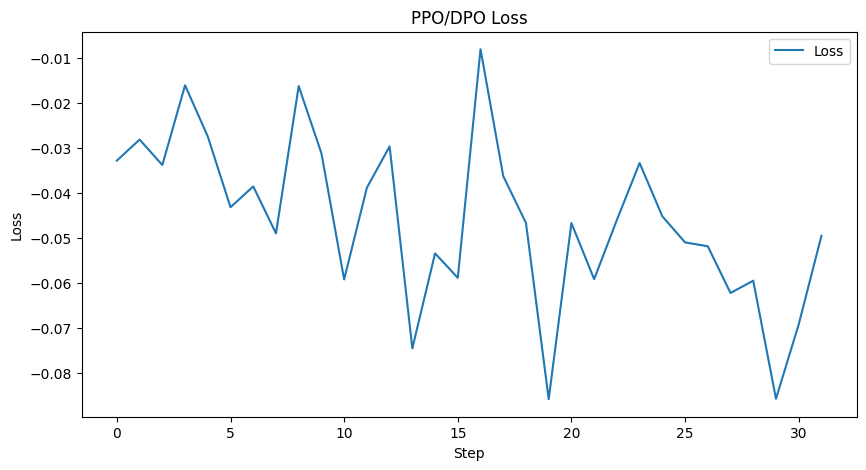

In [ ]:
# For DPOTrainer (or SFTTrainer, GRPOTrainer, RewardTrainer)
history = pd.DataFrame(ppo_history)

# Filter loss entries
loss_logs = history[history["loss"].notna()]

plt.figure(figsize=(10,5))
plt.plot(loss_logs["step"], loss_logs["loss"], label="Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("PPO/DPO Loss")
plt.legend()
plt.savefig(f"{PLOT_DIR}/ppo_loss.png")
plt.show()

In [ ]:
formatted_prompt = f"Question: How are you?\n\nAnswer: "
        
inputs = tokenizer(formatted_prompt, return_tensors="pt").to(DEVICE)

# 2. Generation with Diversity Constraints (prevents policy_model collapse)
with torch.no_grad():
    outputs = policy_model.generate(
        **inputs,
        max_new_tokens=64,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2,      # Crucial to stop loops
        no_repeat_ngram_size=2,       # Prevents phrase stuttering
        pad_token_id=tokenizer.eos_token_id
    )

# 3. Decode and Clean Output
full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
# Extract only the policy_model's generated part (after the prompt)
response = full_text[len(formatted_prompt):].strip()

print(f"{formatted_prompt}{response}")

Question: How are you?

Answer: ㅠ️ I'm super chill! 😊 You know, the kind of person who's just really hard to deal with. Like if someone told me a secret and it took forever or so, that would be weird... but hey man – people have their quirks too 🤯 So what about us humans can
